<a href="https://colab.research.google.com/github/DHung154/Bai-Lab-7-/blob/main/Lab07_ANN_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7 - ANN dự đoán giá xe hơi



## Bước 1: Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Bước 2: Đọc dữ liệu từ GitHub

In [2]:
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/carpricesdata.csv"

df = pd.read_csv(url)

print("Đọc dữ liệu thành công!")
print("Kích thước dữ liệu:", df.shape)
df.head()

Đọc dữ liệu thành công!
Kích thước dữ liệu: (5, 8)


,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,23,46986,1165,90,1,2000,3,13500
1,23,72937,1165,90,1,2000,3,13500
2,24,41711,1165,90,1,2000,3,13950
3,26,48000,1165,90,0,2000,3,14950
4,30,38500,1170,90,0,2000,3,13750


## Bước 3: Kiểm tra dữ liệu

In [3]:
print("Thông tin dữ liệu:")
df.info()

print("\nSố lượng giá trị thiếu ở từng cột:")
print(df.isnull().sum())

print("\nThống kê mô tả:")
df.describe()

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Age       5 non-null      int64
 1   KM        5 non-null      int64
 2   Weight    5 non-null      int64
 3   HP        5 non-null      int64
 4   MetColor  5 non-null      int64
 5   CC        5 non-null      int64
 6   Doors     5 non-null      int64
 7   Price     5 non-null      int64
dtypes: int64(8)
memory usage: 452.0 bytes

Số lượng giá trị thiếu ở từng cột:
Age         0
KM          0
Weight      0
HP          0
MetColor    0
CC          0
Doors       0
Price       0
dtype: int64

Thống kê mô tả:


,Age,KM,Weight,HP,MetColor,CC,Doors,Price
count,5.000000,5.000000,5.000000,5.0,5.000000,5.0,5.0,5.000000
mean,25.200000,49626.800000,1166.000000,90.0,0.600000,2000.0,3.0,13930.000000
std,2.949576,13596.426873,2.236068,0.0,0.547723,0.0,0.0,600.624675
min,23.000000,38500.000000,1165.000000,90.0,0.000000,2000.0,3.0,13500.000000
25%,23.000000,41711.000000,1165.000000,90.0,0.000000,2000.0,3.0,13500.000000
50%,24.000000,46986.000000,1165.000000,90.0,1.000000,2000.0,3.0,13750.000000
75%,26.000000,48000.000000,1165.000000,90.0,1.000000,2000.0,3.0,13950.000000
max,30.000000,72937.000000,1170.000000,90.0,1.000000,2000.0,3.0,14950.000000


## Bước 4: Chọn biến đầu vào X và biến mục tiêu y

In [5]:
# Các cột dùng để dự đoán giá xe
predictors = ["Age", "KM", "Weight", "HP", "MetColor", "CC", "Doors"]

# Cột cần dự đoán
target = "Price"

X = df[predictors]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 7)
y shape: (5,)


## Bước 5: Chia tập train/test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Số mẫu train:", X_train.shape[0])
print("Số mẫu test :", X_test.shape[0])

Số mẫu train: 4
Số mẫu test : 1


## Bước 6: Chuẩn hóa dữ liệu

In [7]:
# Chuẩn hóa input X
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Chuẩn hóa output y để model học ổn định hơn
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

print("Đã chuẩn hóa dữ liệu xong.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train_scaled shape:", y_train_scaled.shape)

Đã chuẩn hóa dữ liệu xong.
X_train_scaled shape: (4, 7)
y_train_scaled shape: (4,)


## Bước 7: Xây dựng mô hình ANN

In [8]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),

    Dense(32, activation="relu"),
    Dropout(0.1),

    Dense(16, activation="relu"),

    # Output cho bài toán hồi quy: 1 neuron, activation linear
    Dense(1, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

## Bước 8: Huấn luyện mô hình

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.2209 - mae: 0.3630 - val_loss: 2.8999 - val_mae: 1.7029
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.2699 - mae: 0.4241 - val_loss: 2.9171 - val_mae: 1.7080
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2577 - mae: 0.4145 - val_loss: 2.9372 - val_mae: 1.7138
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2869 - mae: 0.4444 - val_loss: 2.9640 - val_mae: 1.7216
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.2026 - mae: 0.2969 - val_loss: 2.9976 - val_mae: 1.7314
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.1277 - mae: 0.3086 - val_loss: 3.0323 - val_mae: 1.7413
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.1818 - mae: 0.2991 - val_loss: 3.0682 - val_mae: 1.7516
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.1886 - mae: 0.2919 - val_loss: 3.1059 - val_mae: 1.7624
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.1761 -

## Bước 9: Vẽ biểu đồ Loss và MAE

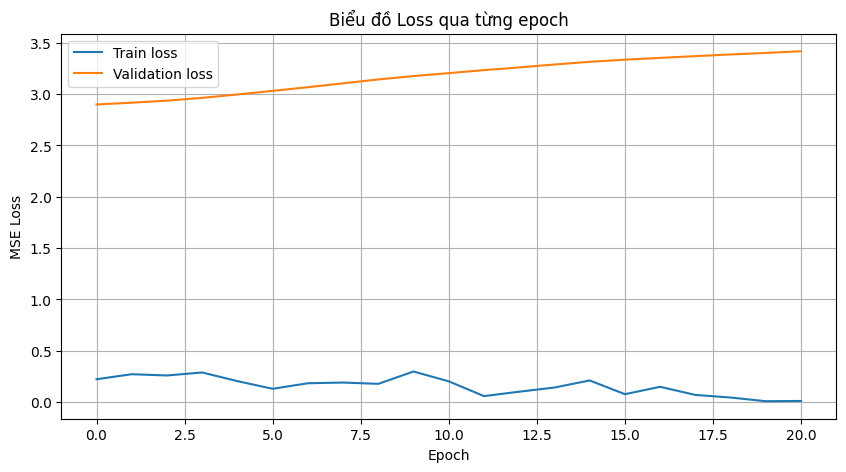

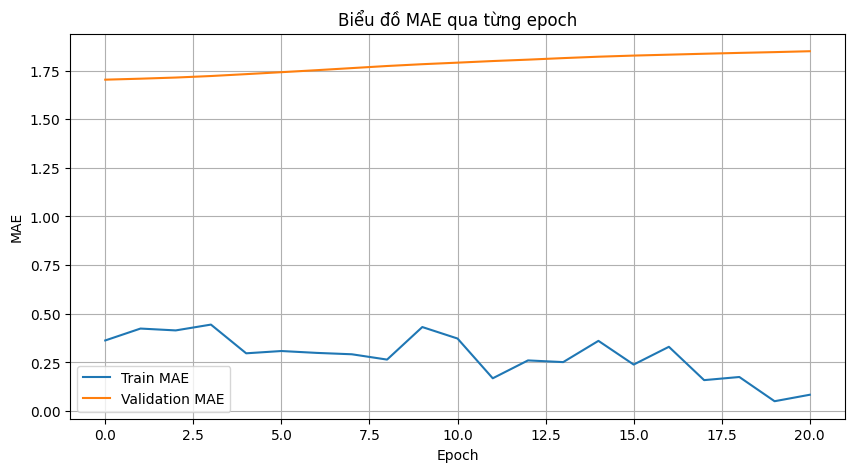

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Biểu đồ Loss qua từng epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("Biểu đồ MAE qua từng epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

## Bước 10: Dự đoán trên tập test

In [12]:
# Dự đoán giá đã chuẩn hóa
y_pred_scaled = model.predict(X_test_scaled)

# Đưa giá trị dự đoán về đơn vị giá thật
y_pred = y_scaler.inverse_transform(y_pred_scaled).ravel()

# y thực tế
y_true = y_test.values

result_df = pd.DataFrame({
    "Giá thực tế": y_true,
    "Giá dự đoán": y_pred,
    "Sai số": y_pred - y_true,
    "Sai số tuyệt đối": np.abs(y_pred - y_true)
})

result_df.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


,Giá thực tế,Giá dự đoán,Sai số,Sai số tuyệt đối
0,13500,13531.572266,31.572266,31.572266


## Bước 11: Đánh giá mô hình

In [13]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ANN")
print("--------------------------------")
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ANN
--------------------------------
MAE : 31.57
RMSE: 31.57
R²  : nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


## Bước 12: Vẽ biểu đồ giá thực tế và giá dự đoán

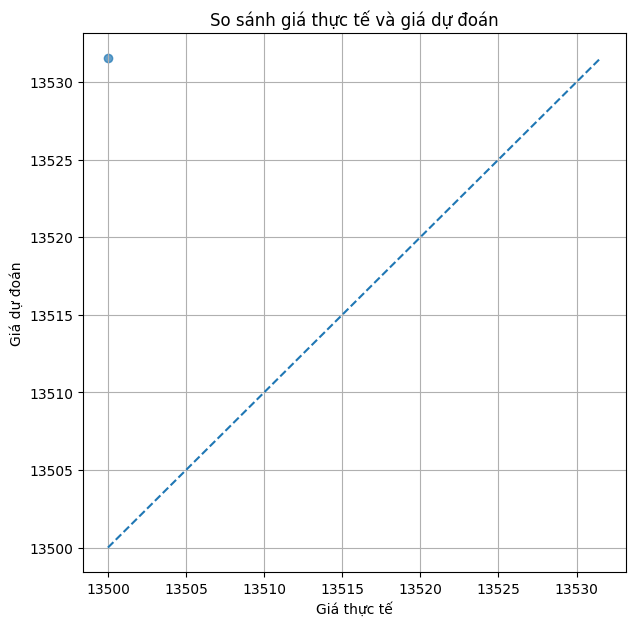

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.7)

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh giá thực tế và giá dự đoán")
plt.grid(True)
plt.show()

## Bước 13: Dự đoán thử một xe mới

In [15]:
# Ví dụ xe mới:
# Age=36 tháng, KM=50000, Weight=1100, HP=110, MetColor=1, CC=1600, Doors=4
new_car = pd.DataFrame([{
    "Age": 36,
    "KM": 50000,
    "Weight": 1100,
    "HP": 110,
    "MetColor": 1,
    "CC": 1600,
    "Doors": 4
}])

new_car_scaled = x_scaler.transform(new_car)
new_price_scaled = model.predict(new_car_scaled)
new_price = y_scaler.inverse_transform(new_price_scaled).ravel()[0]

print(f"Giá xe dự đoán: {new_price:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Giá xe dự đoán: -2,545.86


## Bước 14: Lưu kết quả

In [16]:
result_df.to_csv("ket_qua_du_doan_gia_xe_ANN.csv", index=False)

model.save("model_ANN_du_doan_gia_xe.keras")

print("Đã lưu:")
print("- ket_qua_du_doan_gia_xe_ANN.csv")
print("- model_ANN_du_doan_gia_xe.keras")

Đã lưu:
- ket_qua_du_doan_gia_xe_ANN.csv
- model_ANN_du_doan_gia_xe.keras


Test bằng dữ liệu trên https://www.kaggle.com/datasets/victorahaji/toyota-corolla-car-price-prediction/data

BƯỚC 1: Cài thư viện KaggleHub


In [17]:
!pip install kagglehub[pandas-datasets]

BƯỚC 2: Import thư viện cần dùng

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

BƯỚC 3: Tải dataset Toyota Corolla từ Kaggle

In [19]:
path = kagglehub.dataset_download("victorahaji/toyota-corolla-car-price-prediction")

print("Dataset được tải về tại:", path)
print("Danh sách file trong dataset:")
print(os.listdir(path))

100%|██████████| 30.2k/30.2k [00:00<00:00, 32.9MB/s]

Extracting files...
Dataset được tải về tại: /root/.cache/kagglehub/datasets/victorahaji/toyota-corolla-car-price-prediction/versions/1
Danh sách file trong dataset:
['ToyotaCorolla1.csv']


BƯỚC 4: Đọc file CSV

In [20]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

print("Các file CSV tìm thấy:", csv_files)

file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

print("Kích thước dữ liệu ban đầu:", df.shape)
df.head()

Các file CSV tìm thấy: ['ToyotaCorolla1.csv']
Kích thước dữ liệu ban đầu: (1436, 39)


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


BƯỚC 5: Kiểm tra tên cột trong dataset Kaggle

In [22]:
print("Danh sách cột trong dataset:")
print(df.columns.tolist())

Danh sách cột trong dataset:
['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']


BƯỚC 6: Lọc dữ liệu cho giống bài thầy

In [23]:
# Copy dữ liệu gốc để xử lý
data = df.copy()

# Đổi tên cột cho giống bài thầy nếu dataset Kaggle đặt tên khác
rename_dict = {}

if 'Age_08_04' in data.columns:
    rename_dict['Age_08_04'] = 'Age'

if 'Met_Color' in data.columns:
    rename_dict['Met_Color'] = 'MetColor'

if 'cc' in data.columns:
    rename_dict['cc'] = 'CC'

data = data.rename(columns=rename_dict)

print("Danh sách cột sau khi đổi tên:")
print(data.columns.tolist())

Danh sách cột sau khi đổi tên:
['Id', 'Model', 'Price', 'Age', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'MetColor', 'Color', 'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar']


BƯỚC 7: Chỉ giữ lại các cột

In [24]:
lab_columns = ['Age', 'KM', 'Weight', 'HP', 'MetColor', 'CC', 'Doors', 'Price']

lab_data = data[lab_columns].copy()

print("Kích thước dữ liệu sau khi lọc:", lab_data.shape)
lab_data.head()

Kích thước dữ liệu sau khi lọc: (1436, 8)


,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,23,46986,1165,90,1,2000,3,13500
1,23,72937,1165,90,1,2000,3,13750
2,24,41711,1165,90,1,2000,3,13950
3,26,48000,1165,90,0,2000,3,14950
4,30,38500,1170,90,0,2000,3,13750


BƯỚC 8: Kiểm tra dữ liệu bị thiếu

In [25]:
print("Số lượng giá trị thiếu ở từng cột:")
print(lab_data.isnull().sum())

Số lượng giá trị thiếu ở từng cột:
Age         0
KM          0
Weight      0
HP          0
MetColor    0
CC          0
Doors       0
Price       0
dtype: int64


BƯỚC 9: Kiểm tra kiểu dữ liệu

In [26]:
lab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Age       1436 non-null   int64
 1   KM        1436 non-null   int64
 2   Weight    1436 non-null   int64
 3   HP        1436 non-null   int64
 4   MetColor  1436 non-null   int64
 5   CC        1436 non-null   int64
 6   Doors     1436 non-null   int64
 7   Price     1436 non-null   int64
dtypes: int64(8)
memory usage: 89.9 KB


BƯỚC 10: Ép kiểu dữ liệu về số

In [27]:
for col in lab_columns:
    lab_data[col] = pd.to_numeric(lab_data[col], errors='coerce')

lab_data = lab_data.dropna()

print("Kích thước dữ liệu sau khi ép kiểu số:", lab_data.shape)
lab_data.head()

Kích thước dữ liệu sau khi ép kiểu số: (1436, 8)


,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,23,46986,1165,90,1,2000,3,13500
1,23,72937,1165,90,1,2000,3,13750
2,24,41711,1165,90,1,2000,3,13950
3,26,48000,1165,90,0,2000,3,14950
4,30,38500,1170,90,0,2000,3,13750


BƯỚC 11: Xem thống kê dữ liệu

In [28]:
lab_data.describe()

,Age,KM,Weight,HP,MetColor,CC,Doors,Price
count,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000
mean,55.947075,68533.259749,1072.45961,101.502089,0.674791,1576.85585,4.033426,10730.824513
std,18.599988,37506.448872,52.64112,14.981080,0.468616,424.38677,0.952677,3626.964585
min,1.000000,1.000000,1000.00000,69.000000,0.000000,1300.00000,2.000000,4350.000000
25%,44.000000,43000.000000,1040.00000,90.000000,0.000000,1400.00000,3.000000,8450.000000
50%,61.000000,63389.500000,1070.00000,110.000000,1.000000,1600.00000,4.000000,9900.000000
75%,70.000000,87020.750000,1085.00000,110.000000,1.000000,1600.00000,5.000000,11950.000000
max,80.000000,243000.000000,1615.00000,192.000000,1.000000,16000.00000,5.000000,32500.000000


BƯỚC 12: Tách input và output

In [29]:
Predictors = ['Age', 'KM', 'Weight', 'HP', 'MetColor', 'CC', 'Doors']
TargetVariable = ['Price']

X = lab_data[Predictors].values
y = lab_data[TargetVariable].values

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (1436, 7)
Kích thước y: (1436, 1)


BƯỚC 13: Chia dữ liệu train/test

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Số dòng train:", X_train.shape[0])
print("Số dòng test:", X_test.shape[0])

Số dòng train: 1148
Số dòng test: 288


BƯỚC 14: Chuẩn hóa dữ liệu

In [31]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train_scaled shape:", y_train_scaled.shape)

X_train_scaled shape: (1148, 7)
y_train_scaled shape: (1148, 1)


BƯỚC 15: Xây dựng mô hình ANN

In [32]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

# Output 1 neuron để dự đoán Price
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BƯỚC 16: Train mô hình ANN

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6612 - mae: 0.4990 - val_loss: 0.3067 - val_mae: 0.3671
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1898 - mae: 0.3157 - val_loss: 0.1484 - val_mae: 0.2619
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1163 - mae: 0.2514 - val_loss: 0.1294 - val_mae: 0.2412
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1049 - mae: 0.2394 - val_loss: 0.1185 - val_mae: 0.2337
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0997 - mae: 0.2351 - val_loss: 0.1162 - val_mae: 0.2338
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0985 - mae: 0.2348 - val_loss: 0.1099 - val_mae: 0.2293
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0963 - mae: 0.2320 - val_loss: 0.1117 - val_mae: 0.2322
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0941 - mae: 0.2272 - val_loss: 0.1082 - val_mae: 0.2301
Epoch 9/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.09

BƯỚC 17: Vẽ biểu đồ Loss

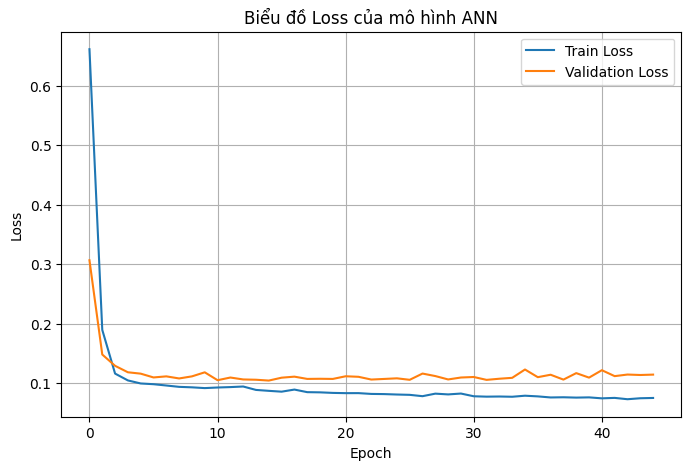

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Biểu đồ Loss của mô hình ANN')
plt.legend()
plt.grid(True)
plt.show()

BƯỚC 18: Vẽ biểu đồ MAE

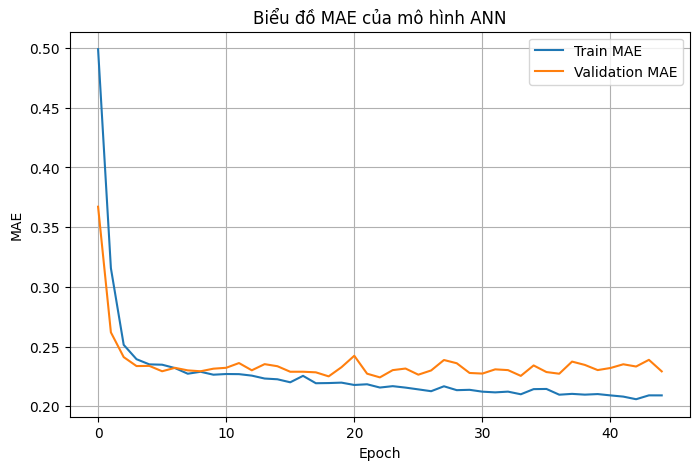

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Biểu đồ MAE của mô hình ANN')
plt.legend()
plt.grid(True)
plt.show()

BƯỚC 19: Dự đoán trên tập test

In [36]:
y_pred_scaled = model.predict(X_test_scaled)

# Chuyển kết quả dự đoán về giá trị Price thật
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# y_test ban đầu đã là giá thật
y_test_real = y_test

print("5 giá trị dự đoán đầu tiên:")
print(y_pred[:5])

print("5 giá trị thực tế đầu tiên:")
print(y_test_real[:5])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5 giá trị dự đoán đầu tiên:
[[10506.827]
 [ 8978.678]
 [ 8991.394]
 [ 8721.297]
 [10007.995]]
5 giá trị thực tế đầu tiên:
[[10800]
 [ 9950]
 [ 7500]
 [ 9250]
 [ 9750]]


Tạo bảng so sánh giá thật và giá dự đoán

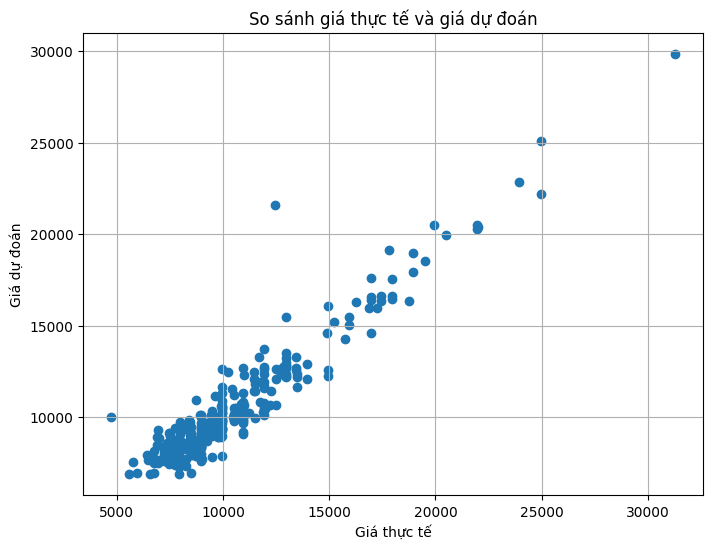

In [37]:
result = pd.DataFrame({
    'Gia_thuc_te': y_test_real.flatten(),
    'Gia_du_doan': y_pred.flatten(),
    'Sai_so': abs(y_test_real.flatten() - y_pred.flatten())
})

result.head(20)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred)
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh giá thực tế và giá dự đoán")
plt.grid(True)
plt.show()

In [38]:
new_car = pd.DataFrame({
    'Age': [60],
    'KM': [80000],
    'Weight': [1050],
    'HP': [110],
    'MetColor': [1],
    'CC': [1600],
    'Doors': [5]
})

new_car_scaled = scaler_X.transform(new_car)

pred_scaled = model.predict(new_car_scaled)

pred_price = scaler_y.inverse_transform(pred_scaled)

print("Giá xe dự đoán:", pred_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Giá xe dự đoán: 9408.283


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
